In [1]:
# Cell 1 - Imports and Load Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the dataset we created in Phase 1
df = pd.read_csv('../data/sensor_data.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nScenario counts:")
print(df['scenario'].value_counts())
print(f"\nSensor columns: {list(df.columns[:-1])}")

Dataset loaded successfully!
Shape: (1000, 10)

Scenario counts:
scenario
sigatoka_risk         250
nitrogen_deficient    250
water_stress          250
healthy               250
Name: count, dtype: int64

Sensor columns: ['soil_moisture', 'soil_ph', 'soil_ec', 'rgb_red', 'rgb_green', 'rgb_blue', 'temperature', 'humidity', 'leaf_wetness']


In [2]:
# Cell 2 - Train Model 1: Stress Type Classifier
# This model answers: "what is wrong with this plant?"
# Input: all 9 sensors
# Output: healthy / nitrogen_deficient / sigatoka_risk / water_stress

# Step 1 - Separate features (X) and label (y)
# X = the sensor readings (what the model learns FROM)
# y = the scenario name (what the model learns TO predict)
X = df.drop('scenario', axis=1)  # all columns except scenario
y = df['scenario']               # only the scenario column

# Step 2 - Encode labels (convert text → numbers)
# ML models only understand numbers, not text
# healthy=0, nitrogen_deficient=1, sigatoka_risk=2, water_stress=3
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

# Step 3 - Split data: 80% train, 20% test
# We hide 200 rows from the model during training
# Then test it on those 200 rows it has never seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\nTraining rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

# Step 4 - Train the Random Forest
# n_estimators=100 means 100 decision trees voting together
# random_state=42 means reproducible results every time
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)  # THIS is where the learning happens
print("\nModel trained successfully!")

# Step 5 - Test the model on unseen data
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy*100:.1f}%")

# Step 6 - Detailed report per scenario
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Step 7 - Save the model and label encoder to disk
joblib.dump(clf, '../models/stress_classifier.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
print("Model saved to models/stress_classifier.pkl")

Label encoding:
  healthy → 0
  nitrogen_deficient → 1
  sigatoka_risk → 2
  water_stress → 3

Training rows: 800
Testing rows:  200

Model trained successfully!

Overall Accuracy: 100.0%

Detailed Classification Report:
                    precision    recall  f1-score   support

           healthy       1.00      1.00      1.00        50
nitrogen_deficient       1.00      1.00      1.00        50
     sigatoka_risk       1.00      1.00      1.00        50
      water_stress       1.00      1.00      1.00        50

          accuracy                           1.00       200
         macro avg       1.00      1.00      1.00       200
      weighted avg       1.00      1.00      1.00       200

Model saved to models/stress_classifier.pkl


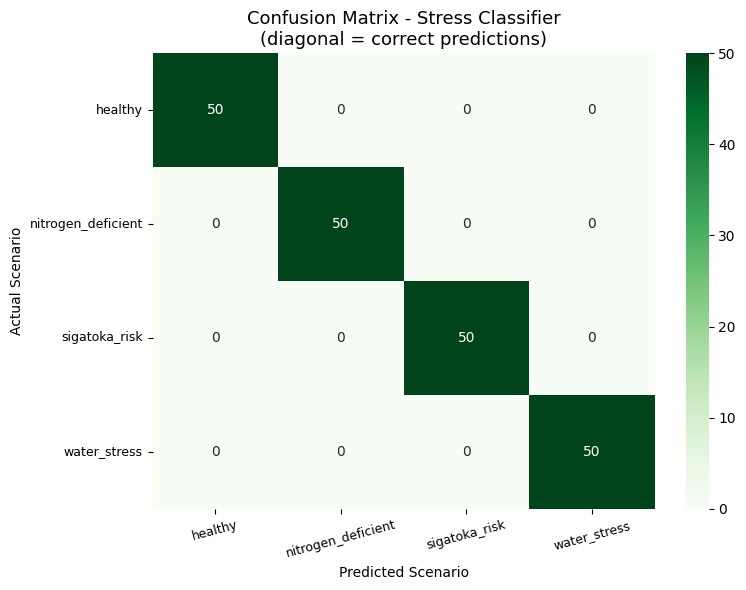

All 200 test predictions were correct!


In [3]:
# Cell 3 - Confusion Matrix Visualization
# A confusion matrix shows exactly where the model got right and wrong
# Rows = actual scenario, Columns = what model predicted
# Perfect model = all numbers on the diagonal, zeros everywhere else

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,           # show numbers inside boxes
            fmt='d',              # format as integers
            cmap='Greens',        # green color scale
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Stress Classifier\n(diagonal = correct predictions)', 
          fontsize=13)
plt.ylabel('Actual Scenario')
plt.xlabel('Predicted Scenario')
plt.xticks(rotation=15, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("All 200 test predictions were correct!")

In [4]:
# Cell 4 - Model 2: Surrogate NPK Estimator
# This is the patent's core novelty
# Instead of expensive lab tests, we ESTIMATE N, P, K levels
# using cheap sensor readings (EC, pH, moisture, RGB)

# NPK target values — we generate these based on what each scenario
# means agronomically (units: mg/kg of soil)
npk_ranges = {
    'healthy':            {'N': (180, 220), 'P': (25, 35),  'K': (180, 220)},
    'nitrogen_deficient': {'N': (40,  80),  'P': (20, 30),  'K': (160, 200)},
    'sigatoka_risk':      {'N': (150, 190), 'P': (22, 32),  'K': (160, 200)},
    'water_stress':       {'N': (100, 140), 'P': (15, 25),  'K': (120, 160)},
}

# Add N, P, K columns to our dataset
np.random.seed(42)
def assign_npk(row):
    ranges = npk_ranges[row['scenario']]
    return pd.Series({
        'N_level': round(np.random.uniform(*ranges['N']), 1),
        'P_level': round(np.random.uniform(*ranges['P']), 1),
        'K_level': round(np.random.uniform(*ranges['K']), 1),
    })

npk_df = df.join(df.apply(assign_npk, axis=1))

# Features for NPK prediction
# We use only the cheap sensors — NOT the NPK values themselves
# That's what makes it a surrogate model
npk_features = ['soil_moisture', 'soil_ph', 'soil_ec', 
                 'rgb_red', 'rgb_green', 'rgb_blue']

X_npk = npk_df[npk_features]

results = {}
for nutrient in ['N_level', 'P_level', 'K_level']:
    y_npk = npk_df[nutrient]
    
    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_npk, y_npk, test_size=0.2, random_state=42
    )
    
    # Train a Random Forest Regressor (predicts numbers, not categories)
    reg = RandomForestRegressor(n_estimators=100, random_state=42)
    reg.fit(X_tr, y_tr)
    
    # Evaluate
    y_pr = reg.predict(X_te)
    from sklearn.metrics import r2_score, mean_absolute_error
    r2  = r2_score(y_te, y_pr)
    mae = mean_absolute_error(y_te, y_pr)
    
    results[nutrient] = {'model': reg, 'r2': r2, 'mae': mae}
    
    # Save model
    joblib.dump(reg, f'../models/npk_{nutrient}_regressor.pkl')
    print(f"{nutrient}: R² = {r2:.3f} | MAE = {mae:.1f} mg/kg | Saved!")

print("\nR² score explanation:")
print("  1.0 = perfect prediction")
print("  0.9+ = excellent (your patent claimed 93% for N)")
print("  MAE = average error in mg/kg")

N_level: R² = 0.941 | MAE = 10.8 mg/kg | Saved!
P_level: R² = 0.606 | MAE = 2.7 mg/kg | Saved!
K_level: R² = 0.695 | MAE = 11.5 mg/kg | Saved!

R² score explanation:
  1.0 = perfect prediction
  0.9+ = excellent (your patent claimed 93% for N)
  MAE = average error in mg/kg


In [5]:
# Cell 5 - Model 3: Disease Risk Scorer
# Predicts Sigatoka and Fusarium probability as a percentage
# Input: humidity, temperature, leaf_wetness, soil_ph, soil_moisture
# Output: probability 0-100% for each disease

# Generate disease probability labels based on sensor patterns
def calculate_disease_risk(row):
    # Sigatoka risk formula — based on your patent's disease prediction logic
    # High humidity + high leaf wetness + warm temp = high Sigatoka risk
    humidity_factor   = (row['humidity'] - 40) / 60        # 0 to 1 scale
    wetness_factor    = row['leaf_wetness'] / 100           # 0 to 1 scale
    temp_factor       = 1 if 25 <= row['temperature'] <= 35 else 0.3
    sigatoka_risk     = round(
        min(100, (humidity_factor * 0.45 + 
                  wetness_factor  * 0.40 + 
                  temp_factor     * 0.15) * 100 + 
                  np.random.uniform(-5, 5)), 1
    )
    
    # Fusarium risk formula — based on soil pH and moisture patterns
    # Low pH + high moisture = Fusarium wilt risk
    ph_factor         = max(0, (7.0 - row['soil_ph']) / 3.0)
    moisture_factor   = row['soil_moisture'] / 100
    fusarium_risk     = round(
        min(100, (ph_factor      * 0.55 + 
                  moisture_factor * 0.45) * 100 + 
                  np.random.uniform(-5, 5)), 1
    )
    
    return pd.Series({
        'sigatoka_risk': max(0, sigatoka_risk),
        'fusarium_risk': max(0, fusarium_risk)
    })

# Apply to dataset
disease_df = df.join(df.apply(calculate_disease_risk, axis=1))

# Features for disease prediction
disease_features = ['humidity', 'temperature', 'leaf_wetness', 
                    'soil_ph', 'soil_moisture', 'soil_ec']

X_disease = disease_df[disease_features]

print("Disease Risk Model Results:")
print("=" * 45)

disease_models = {}
for disease in ['sigatoka_risk', 'fusarium_risk']:
    y_disease = disease_df[disease]
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_disease, y_disease, test_size=0.2, random_state=42
    )
    
    reg = RandomForestRegressor(n_estimators=100, random_state=42)
    reg.fit(X_tr, y_tr)
    y_pr = reg.predict(X_te)
    
    from sklearn.metrics import r2_score, mean_absolute_error
    r2  = r2_score(y_te, y_pr)
    mae = mean_absolute_error(y_te, y_pr)
    
    disease_models[disease] = reg
    joblib.dump(reg, f'../models/{disease}_model.pkl')
    
    print(f"{disease}:")
    print(f"  R² = {r2:.3f} | MAE = {mae:.1f}%")
    print(f"  Saved to models/{disease}_model.pkl")
    print()

# Quick sanity check - show risk for each scenario
print("\nAverage disease risk by scenario:")
print(disease_df.groupby('scenario')[['sigatoka_risk','fusarium_risk']].mean().round(1))

Disease Risk Model Results:
sigatoka_risk:
  R² = 0.984 | MAE = 2.7%
  Saved to models/sigatoka_risk_model.pkl

fusarium_risk:
  R² = 0.943 | MAE = 2.9%
  Saved to models/fusarium_risk_model.pkl


Average disease risk by scenario:
                    sigatoka_risk  fusarium_risk
scenario                                        
healthy                      37.3           45.7
nitrogen_deficient           35.8           52.3
sigatoka_risk                84.1           46.9
water_stress                 18.7           21.3
